# Notebook 02 — Storm Classification (Pegasus Bay)
This notebook continues from "01_explore_buoy.ipynb" and performs clustering on the set of detected storm events to identify distinct storm types based on peak wave height, duration, period, and direction.


In [3]:
# Notebook 02 – Storm Classification (Pegasus Bay)
# This notebook continues from 01_explore_buoy.ipynb and performs clustering
# on detected storm events to identify distinct storm types based on wave characteristics.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Better plot size for time series and scatter plots
plt.rcParams["figure.figsize"] = (10, 4)

# Project root directory and cleaned dataset path
project_root = "C:/Users/anura/Downloads/DATA601-Project"
clean_path = os.path.join(project_root, "data_processed", "PegasusBay_buoy_clean.csv")

print("Loading cleaned buoy data from:", clean_path)
df = pd.read_csv(clean_path)

df.head()  # preview first rows


Loading cleaned buoy data from: C:/Users/anura/Downloads/DATA601-Project\data_processed\PegasusBay_buoy_clean.csv


,time,Site,BuoyID,Hsig (m),Tp (s),Tm (s),Dp (deg),DpSpr (deg),Dm (deg),DmSpr (deg),QF_waves,WindSpeed (m/s),WindDirec (deg)
0,2024-04-09 13:24:30+00:00,SPOT-31020C,SPOT-31020C,1.32,7.88,4.90,58.961,26.749,52.714,51.744,1,9.2,342
1,2024-04-09 14:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,4.96,57.969,21.884,51.613,48.464,1,9.6,257
2,2024-04-09 15:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,5.20,55.614,23.537,53.875,46.087,1,8.8,337
3,2024-04-09 16:24:30+00:00,SPOT-31020C,SPOT-31020C,1.25,7.88,5.18,54.888,23.241,53.431,43.849,1,8.0,337
4,2024-04-09 17:24:30+00:00,SPOT-31020C,SPOT-31020C,1.10,7.88,5.14,62.259,26.304,56.090,43.794,1,7.2,342


In [4]:
# Convert the time column to datetime and set as index
time_col = "time"  
df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")
df = df.dropna(subset=[time_col])         # remove rows where timestamp failed
df = df.sort_values(time_col).set_index(time_col)

df.head()


,Site,BuoyID,Hsig (m),Tp (s),Tm (s),Dp (deg),DpSpr (deg),Dm (deg),DmSpr (deg),QF_waves,WindSpeed (m/s),WindDirec (deg)
time,,,,,,,,,,,,
2024-04-09 13:24:30+00:00,SPOT-31020C,SPOT-31020C,1.32,7.88,4.90,58.961,26.749,52.714,51.744,1,9.2,342
2024-04-09 14:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,4.96,57.969,21.884,51.613,48.464,1,9.6,257
2024-04-09 15:24:30+00:00,SPOT-31020C,SPOT-31020C,1.34,7.88,5.20,55.614,23.537,53.875,46.087,1,8.8,337
2024-04-09 16:24:30+00:00,SPOT-31020C,SPOT-31020C,1.25,7.88,5.18,54.888,23.241,53.431,43.849,1,8.0,337
2024-04-09 17:24:30+00:00,SPOT-31020C,SPOT-31020C,1.10,7.88,5.14,62.259,26.304,56.090,43.794,1,7.2,342


In [5]:
# Storm threshold based on regional wave climatology
storm_threshold = 2.5  # metres

# Boolean column: True where Hsig exceeds threshold
df["storm"] = df["Hsig (m)"] > storm_threshold

# Quick check of how many timestamps exceed the threshold
df["storm"].value_counts()


storm
False    12980
True       247
Name: count, dtype: int64

In [6]:
# Detect continuous time windows of storm conditions
storms = []
in_storm = False
times = df.index

for i in range(len(df)):
    is_storm = df["storm"].iloc[i]
    
    if is_storm and not in_storm:
        # Storm begins here
        start = times[i]
        in_storm = True
    elif (not is_storm) and in_storm:
        # Storm ends at the previous timestamp
        end = times[i - 1]
        storms.append((start, end))
        in_storm = False

# Close final storm if the series ended while still in a storm
if in_storm:
    storms.append((start, times[-1]))

print("Number of storm events detected:", len(storms))
storms[:5]  # show first few


Number of storm events detected: 32


[(Timestamp('2024-06-13 05:40:00+0000', tz='UTC'),
  Timestamp('2024-06-13 08:40:00+0000', tz='UTC')),
 (Timestamp('2024-06-14 16:40:00+0000', tz='UTC'),
  Timestamp('2024-06-14 22:40:00+0000', tz='UTC')),
 (Timestamp('2024-06-15 00:40:00+0000', tz='UTC'),
  Timestamp('2024-06-15 06:40:00+0000', tz='UTC')),
 (Timestamp('2024-06-25 23:45:00+0000', tz='UTC'),
  Timestamp('2024-06-27 12:45:00+0000', tz='UTC')),
 (Timestamp('2024-06-27 14:45:00+0000', tz='UTC'),
  Timestamp('2024-06-27 19:45:00+0000', tz='UTC'))]

In [7]:
# For each storm window, calculate summary metrics
storm_events = []

for start, end in storms:
    event = df.loc[start:end]  # subset of the time series belonging to this storm
    
    storm_events.append({
        "start": start,
        "end": end,
        "duration_hours": (end - start).total_seconds() / 3600,
        "peak_Hs": event["Hsig (m)"].max(),
        "mean_Hs": event["Hsig (m)"].mean(),
        "mean_Tp": event["Tp (s)"].mean(),     # swell vs wind-sea indicator
        "mean_direction": event["Dp (deg)"].mean()  # storm source direction
    })

storm_df = pd.DataFrame(storm_events)
storm_df.head()


,start,end,duration_hours,peak_Hs,mean_Hs,mean_Tp,mean_direction
0,2024-06-13 05:40:00+00:00,2024-06-13 08:40:00+00:00,3.0,2.71,2.582500,11.380000,103.013000
1,2024-06-14 16:40:00+00:00,2024-06-14 22:40:00+00:00,6.0,2.87,2.770000,10.565714,66.777571
2,2024-06-15 00:40:00+00:00,2024-06-15 06:40:00+00:00,6.0,2.76,2.648571,11.217143,58.843857
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.0,3.39,2.933947,13.002105,69.408921
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.0,2.95,2.778333,12.800000,76.310833


In [8]:
# Remove storms where wave period or direction could not be computed
storm_df_clean = storm_df.dropna(subset=["mean_Tp", "mean_direction"]).copy()

# Ensure directions lie within 0–360 degrees
storm_df_clean["mean_direction"] = storm_df_clean["mean_direction"] % 360

storm_df_clean.describe()


,duration_hours,peak_Hs,mean_Hs,mean_Tp,mean_direction
count,32.000000,32.000000,32.000000,32.000000,32.000000
mean,6.721354,2.895938,2.741575,13.384404,98.891913
std,12.434589,0.488103,0.285894,4.139910,29.289848
min,0.000000,2.510000,2.510000,10.240000,58.843857
25%,0.000000,2.580000,2.575000,11.380000,78.715688
50%,1.000000,2.745000,2.640000,12.800000,99.057375
75%,6.000000,2.920000,2.772083,12.816458,107.688937
max,47.000000,4.510000,3.770000,25.600000,213.136000


In [9]:
# Select numerical features for clustering
features = ["peak_Hs", "duration_hours", "mean_Tp", "mean_direction"]
X = storm_df_clean[features].values

# Standardize features to equalize scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quick silhouette check for k = 2, 3, 4
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k} → silhouette = {score:.3f}")


k = 2 → silhouette = 0.636
k = 3 → silhouette = 0.677
k = 4 → silhouette = 0.384


C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
# Choose number of clusters based on silhouette inspection
k = 3  # adjust if needed

kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
storm_df_clean["cluster"] = kmeans.fit_predict(X_scaled)

storm_df_clean.head()


C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,start,end,duration_hours,peak_Hs,mean_Hs,mean_Tp,mean_direction,cluster
0,2024-06-13 05:40:00+00:00,2024-06-13 08:40:00+00:00,3.0,2.71,2.582500,11.380000,103.013000,0
1,2024-06-14 16:40:00+00:00,2024-06-14 22:40:00+00:00,6.0,2.87,2.770000,10.565714,66.777571,0
2,2024-06-15 00:40:00+00:00,2024-06-15 06:40:00+00:00,6.0,2.76,2.648571,11.217143,58.843857,0
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,37.0,3.39,2.933947,13.002105,69.408921,1
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,5.0,2.95,2.778333,12.800000,76.310833,0


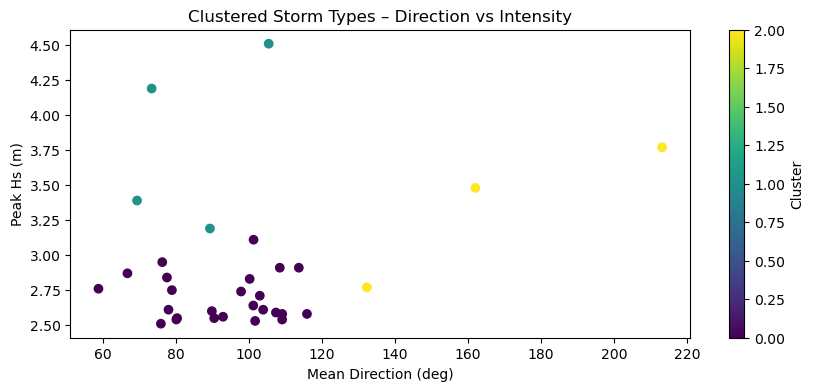

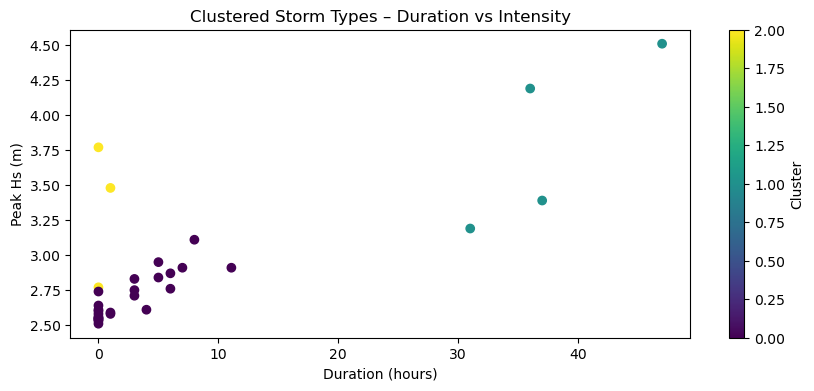

In [11]:
# Cluster plot: direction vs intensity
plt.scatter(
    storm_df_clean["mean_direction"],
    storm_df_clean["peak_Hs"],
    c=storm_df_clean["cluster"]
)
plt.xlabel("Mean Direction (deg)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types – Direction vs Intensity")
plt.colorbar(label="Cluster")
plt.show()

# Cluster plot: duration vs intensity
plt.scatter(
    storm_df_clean["duration_hours"],
    storm_df_clean["peak_Hs"],
    c=storm_df_clean["cluster"]
)
plt.xlabel("Duration (hours)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types – Duration vs Intensity")
plt.colorbar(label="Cluster")
plt.show()


In [12]:
# Statistics to understand physical meaning of each cluster
cluster_stats = storm_df_clean.groupby("cluster").agg({
    "peak_Hs": ["mean", "min", "max"],
    "duration_hours": ["mean", "min", "max"],
    "mean_Tp": ["mean"],
    "mean_direction": ["mean"],
    "start": ["count"]
})
cluster_stats


peak_Hs             duration_hours                     mean_Tp  \
           mean   min   max           mean   min        max       mean   
cluster                                                                  
0        2.6948  2.51  3.11       2.523333   0.0  11.083333  12.137114   
1        3.8200  3.19  4.51      37.750000  31.0  47.000000  12.018264   
2        3.3400  2.77  3.77       0.333333   0.0   1.000000  25.600000   

        mean_direction start  
                  mean count  
cluster                       
0            92.777027    25  
1            84.408889     4  
2           169.160000     3

In [13]:
# Convert numeric cluster IDs into named storm types
# (update this mapping based on cluster_stats results)
def label_storm_type(row):
    if row["cluster"] == 0:
        return "Type A – easterly wind-sea"
    elif row["cluster"] == 1:
        return "Type B – southern swell"
    else:
        return "Type C – hybrid / transitional"

storm_df_clean["storm_type"] = storm_df_clean.apply(label_storm_type, axis=1)

storm_df_clean[["start", "end", "peak_Hs", "duration_hours", "mean_direction", "storm_type"]].head()


,start,end,peak_Hs,duration_hours,mean_direction,storm_type
0,2024-06-13 05:40:00+00:00,2024-06-13 08:40:00+00:00,2.71,3.0,103.013000,Type A – easterly wind-sea
1,2024-06-14 16:40:00+00:00,2024-06-14 22:40:00+00:00,2.87,6.0,66.777571,Type A – easterly wind-sea
2,2024-06-15 00:40:00+00:00,2024-06-15 06:40:00+00:00,2.76,6.0,58.843857,Type A – easterly wind-sea
3,2024-06-25 23:45:00+00:00,2024-06-27 12:45:00+00:00,3.39,37.0,69.408921,Type B – southern swell
4,2024-06-27 14:45:00+00:00,2024-06-27 19:45:00+00:00,2.95,5.0,76.310833,Type A – easterly wind-sea


In [14]:
# Final storm typology summary
type_summary = storm_df_clean.groupby("storm_type").agg(
    count=("start", "count"),
    mean_peak_Hs=("peak_Hs", "mean"),
    max_peak_Hs=("peak_Hs", "max"),
    mean_duration_h=("duration_hours", "mean"),
    mean_direction_deg=("mean_direction", "mean"),
    mean_Tp_s=("mean_Tp", "mean"),
).reset_index()

type_summary


,storm_type,count,mean_peak_Hs,max_peak_Hs,mean_duration_h,mean_direction_deg,mean_Tp_s
0,Type A – easterly wind-sea,25,2.6948,3.11,2.523333,92.777027,12.137114
1,Type B – southern swell,4,3.8200,4.51,37.750000,84.408889,12.018264
2,Type C – hybrid / transitional,3,3.3400,3.77,0.333333,169.160000,25.600000


In [15]:
import os

os.makedirs("../results/tables", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

print("Export folders ready")


Export folders ready


In [17]:
type_summary.to_csv("../results/tables/storm_typology_summary.csv", index=False)
type_summary.to_excel("../results/tables/storm_typology_summary.xlsx", index=False)

print("Summary table exported to results/tables/")


Summary table exported to results/tables/


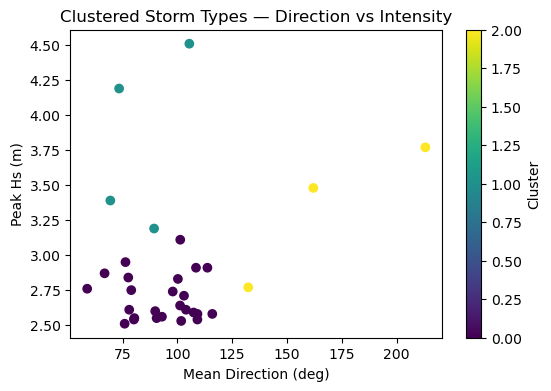

Figure saved: cluster_direction_vs_intensity.png


In [18]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(
    storm_df_clean["mean_direction"],
    storm_df_clean["peak_Hs"],
    c=storm_df_clean["cluster"],
    cmap="viridis"
)
plt.xlabel("Mean Direction (deg)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types — Direction vs Intensity")
plt.colorbar(scatter, label="Cluster")

plt.savefig("../results/figures/cluster_direction_vs_intensity.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved: cluster_direction_vs_intensity.png")


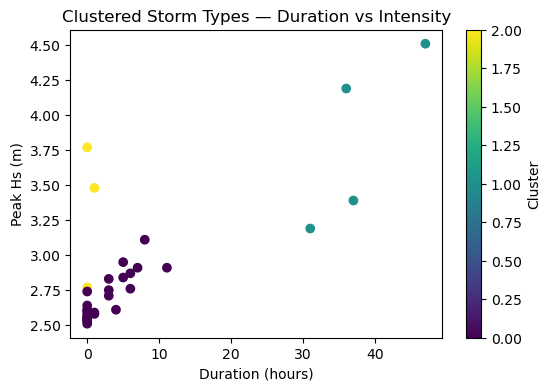

Figure saved: cluster_duration_vs_intensity.png


In [19]:
plt.figure(figsize=(6,4))
scatter = plt.scatter(
    storm_df_clean["duration_hours"],
    storm_df_clean["peak_Hs"],
    c=storm_df_clean["cluster"],
    cmap="viridis"
)
plt.xlabel("Duration (hours)")
plt.ylabel("Peak Hs (m)")
plt.title("Clustered Storm Types — Duration vs Intensity")
plt.colorbar(scatter, label="Cluster")

plt.savefig("../results/figures/cluster_duration_vs_intensity.png",
            dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved: cluster_duration_vs_intensity.png")
